In [ ]:
import os
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# Paths to the train and test directories
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}


# Function to extract paths and labels
def get_paths_and_labels(directory):
    paths = []
    labels = []
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if os.path.isdir(folder_path):  # Check if it's a directory
            label = labels_dict.get(folder, 'Unknown')  # Get label based on folder name
            for filename in os.listdir(folder_path):
                file_path = os.path.join(folder_path, filename)
                paths.append(file_path)
                labels.append(label)
    return paths, labels

# Get train paths and labels
train_paths, train_labels = get_paths_and_labels(train_dir)

# Get test paths and labels
test_paths, test_labels = get_paths_and_labels(test_dir)

# Combine train and test data
all_paths = train_paths + test_paths
all_labels = train_labels + test_labels

# Create a DataFrame
df = pd.DataFrame({
    'path': all_paths,
    'label': all_labels
})

# Load only the TRAIN data for splitting into train/val
train_paths, train_labels = get_paths_and_labels(train_dir)

# Create DataFrame for training data only
train_df = pd.DataFrame({
    'path': train_paths,
    'label': train_labels
})

print("Full training data distribution:")
print(train_df['label'].value_counts())

# Split into train and validation (stratified)
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print("\nAfter split - Training set:")
print(train_df_split['label'].value_counts())
print("\nValidation set:")
print(val_df['label'].value_counts())

# Create separate test DataFrame (no augmentation, untouched)
test_paths, test_labels = get_paths_and_labels(test_dir)
test_df = pd.DataFrame({
    'path': test_paths,
    'label': test_labels
})

print("\nTest set (hold-out) distribution:")
print(test_df['label'].value_counts())


2026-01-08 07:04:59.044100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767855899.226247      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767855899.275137      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767855899.679009      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767855899.679051      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767855899.679054      23 computation_placer.cc:177] computation placer alr

Full training data distribution:
label
Normal                               75709
Murmur                                8405
Premature Ventricular Contraction     6431
Ventricular Tachycardia               5789
Supraventricular Tachycardia          2223
Atrial Fibrillation                    642
Name: count, dtype: int64

After split - Training set:
label
Normal                               60567
Murmur                                6724
Premature Ventricular Contraction     5145
Ventricular Tachycardia               4631
Supraventricular Tachycardia          1778
Atrial Fibrillation                    514
Name: count, dtype: int64

Validation set:
label
Normal                               15142
Murmur                                1681
Premature Ventricular Contraction     1286
Ventricular Tachycardia               1158
Supraventricular Tachycardia           445
Atrial Fibrillation                    128
Name: count, dtype: int64

Test set (hold-out) distribution:
label
Normal    

In [2]:
df

,path,label
0,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
1,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
2,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
3,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
4,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
...,...,...
123993,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123994,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123995,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123996,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia


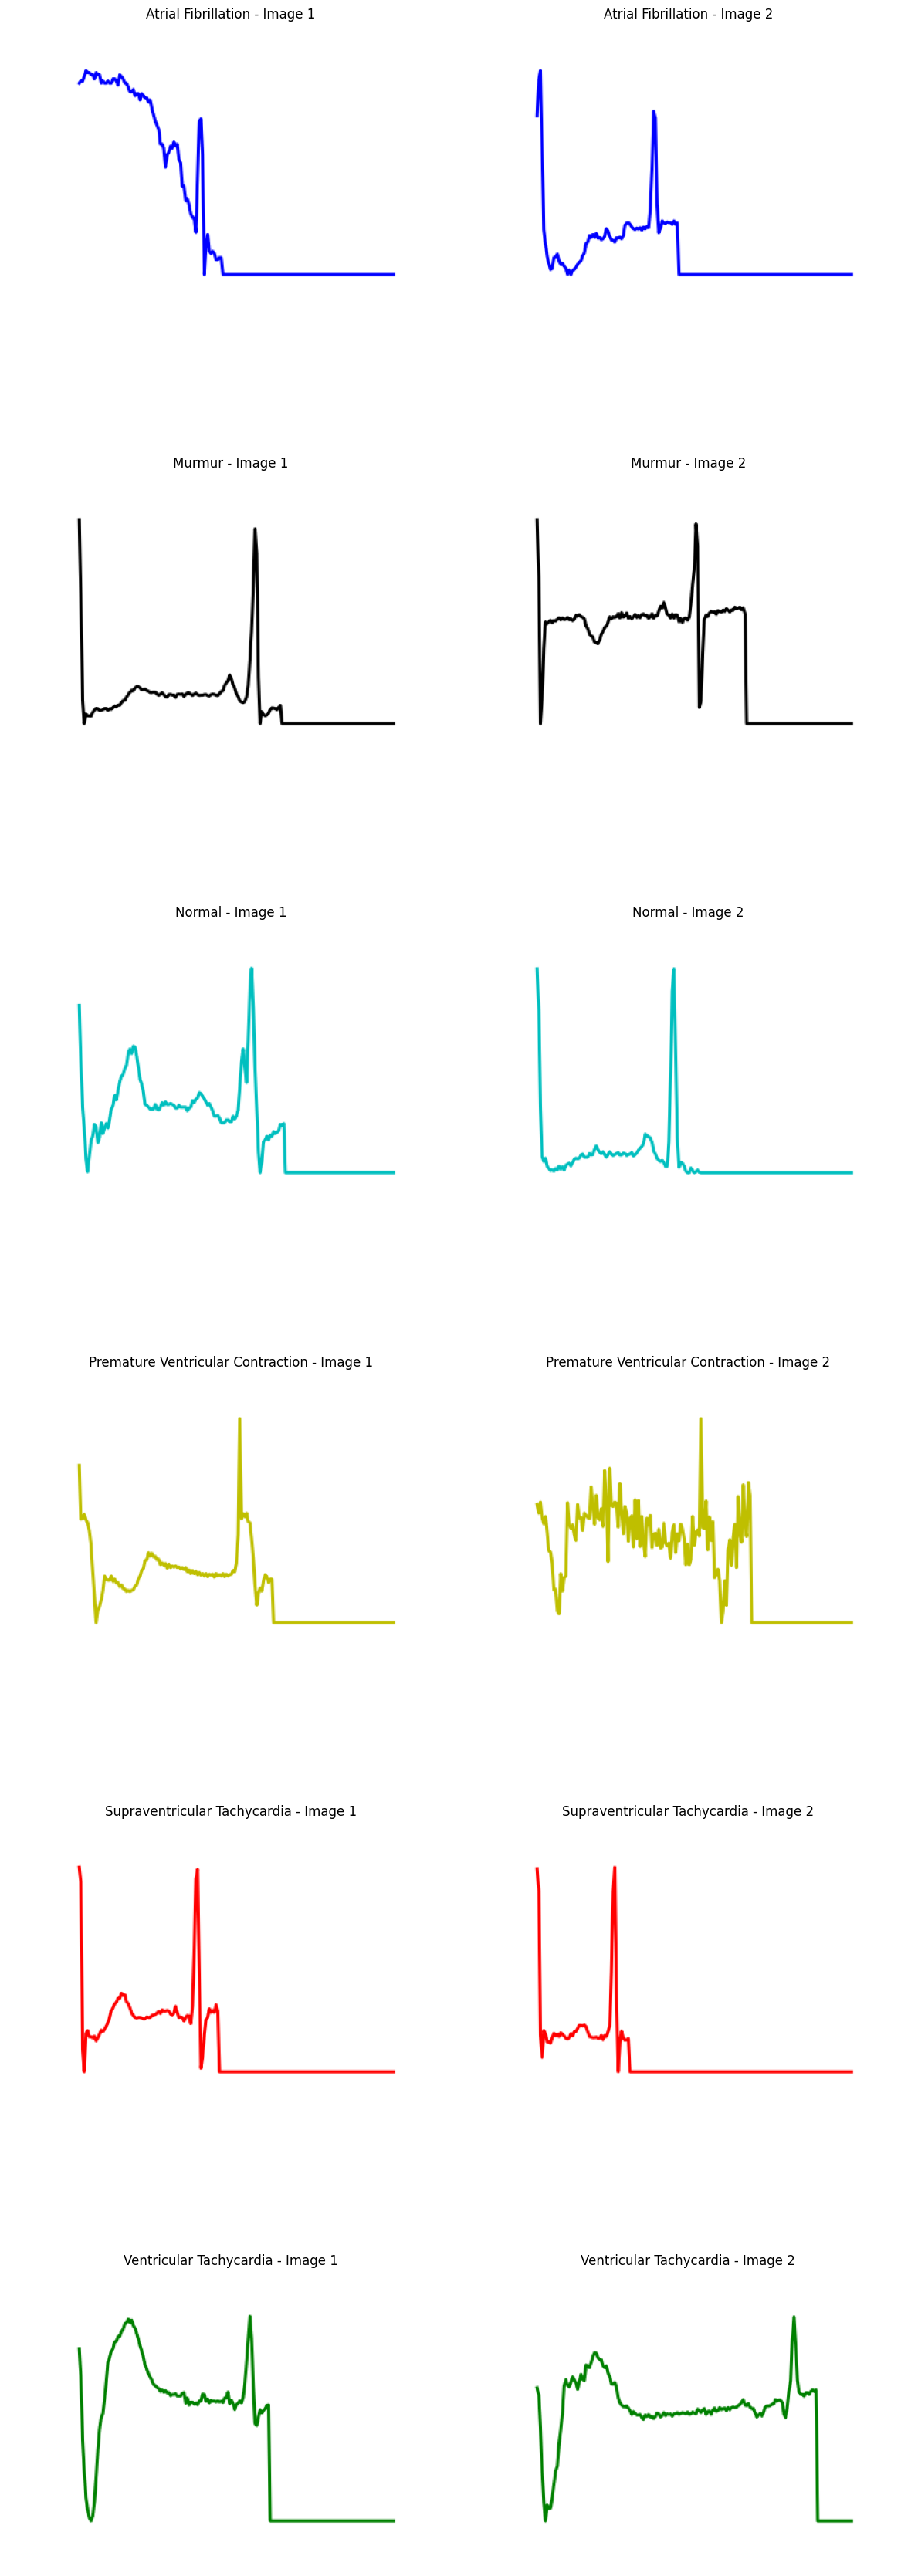

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to load images for each class
def load_images_for_class(class_name, num_images=2):
    class_folder = os.path.join(train_dir, class_name)
    images = []
    for filename in os.listdir(class_folder)[:num_images]:
        image_path = os.path.join(class_folder, filename)
        images.append(image_path)
    return images

# Calculate the number of rows based on the number of classes
num_classes = len(labels_dict)
num_images_per_class = 2  # Number of images per class
rows = num_classes  # Each class will take one row with two images

# Set up the plot size dynamically based on the number of rows and images per row
fig, axes = plt.subplots(rows, num_images_per_class, figsize=(12, rows*6))
axes = axes.ravel()  # Flatten the axes to make it easier to index

# Loop through each class and display two images side by side
for idx, (class_key, class_label) in enumerate(labels_dict.items()):
    images = load_images_for_class(class_key, num_images=num_images_per_class)
    
    for i, image_path in enumerate(images):
        img = mpimg.imread(image_path)
        ax = axes[idx * num_images_per_class + i]  # Select the correct subplot
        ax.imshow(img)
        ax.set_title(f"{class_label} - Image {i+1}")
        ax.axis('off')  # Hide axis

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


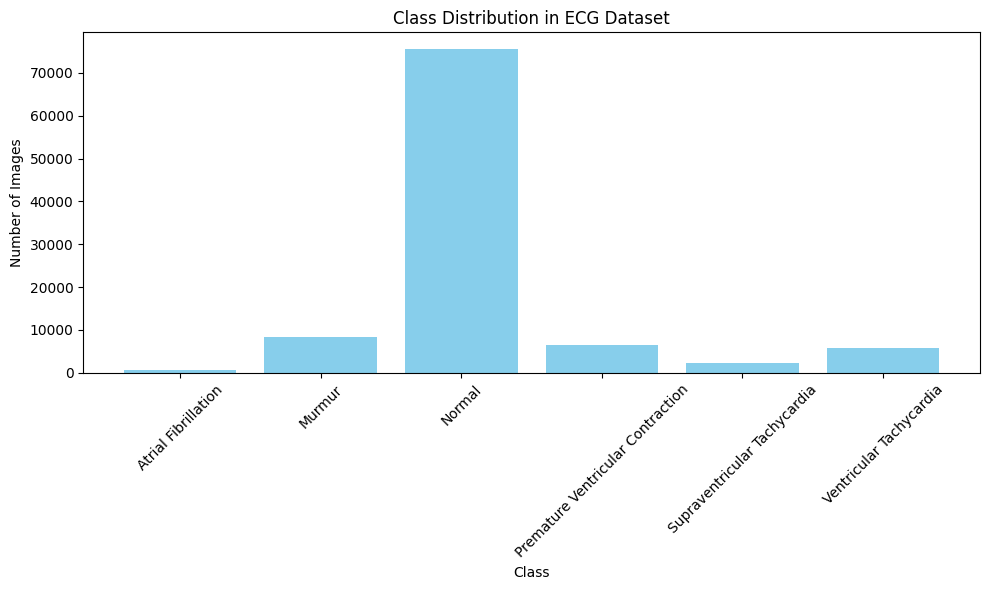

In [4]:
# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to count images for each class
def count_images_for_classes(directory):
    class_counts = {label: 0 for label in labels_dict.values()}
    for folder in os.listdir(directory):
        if folder in labels_dict:
            class_label = labels_dict[folder]
            class_folder = os.path.join(directory, folder)
            num_images = len(os.listdir(class_folder))
            class_counts[class_label] += num_images
    return class_counts

# Get the class distribution
class_distribution = count_images_for_classes(train_dir)

# Create a DataFrame for visualization
df_class_distribution = pd.DataFrame(list(class_distribution.items()), columns=['Class', 'Count'])

# Plot the class distribution
plt.figure(figsize=(10, 6))
plt.bar(df_class_distribution['Class'], df_class_distribution['Count'], color='skyblue')
plt.title('Class Distribution in ECG Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
df['label'].value_counts()

label
Normal                               94635
Murmur                               10506
Premature Ventricular Contraction     8039
Ventricular Tachycardia               7236
Supraventricular Tachycardia          2779
Atrial Fibrillation                    803
Name: count, dtype: int64

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import albumentations as A
from shutil import copyfile

# Define the heavy augmentation pipeline using Albumentations
heavy_aug = A.Compose([
    A.Rotate(limit=30, p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),  # Good for ECG waveform distortion
])

# Output directory for the balanced dataset
output_train_dir = '/kaggle/working/balanced_train'
os.makedirs(output_train_dir, exist_ok=True)

# Create subfolders for each class in the output directory
labels = list(labels_dict.values())  # ['Atrial Fibrillation', 'Murmur', ...]
for label in labels:
    os.makedirs(os.path.join(output_train_dir, label), exist_ok=True)

# Target number of images per class (choose something reasonable)
# Your minority classes have ~800-10k, Normal has ~94k
# Let's aim for 7000 images per class (as you mentioned "take only 7K records" for Normal)
target_per_class = 7000

# Use only the original TRAIN folder data for creating the balanced set
train_paths, train_labels = get_paths_and_labels(train_dir)
train_df = pd.DataFrame({'path': train_paths, 'label': train_labels})

# Group by label
grouped = train_df.groupby('label')

print("Starting offline balancing with augmentation...")

for label, group in grouped:
    label_folder = os.path.join(output_train_dir, label)
    current_images = group['path'].tolist()
    num_current = len(current_images)
    
    print(f"\nProcessing class: {label} ({num_current} original images) -> target {target_per_class}")
    
    if num_current >= target_per_class:
        # Undersample majority (e.g., Normal)
        selected = np.random.choice(current_images, target_per_class, replace=False)
        for src_path in tqdm(selected, desc=f"Copying {label}"):
            filename = os.path.basename(src_path)
            dst_path = os.path.join(label_folder, filename)
            copyfile(src_path, dst_path)
    else:
        # Oversample minority with augmentation
        # First, copy all originals
        for src_path in tqdm(current_images, desc=f"Copying originals {label}"):
            filename = os.path.basename(src_path)
            dst_path = os.path.join(label_folder, filename)
            copyfile(src_path, dst_path)
        
        # Calculate how many augmented images needed
        needed = target_per_class - num_current
        
        # We'll cycle through original images and augment them
        aug_count = 0
        idx = 0
        with tqdm(total=needed, desc=f"Augmenting {label}") as pbar:
            while aug_count < needed:
                img_path = current_images[idx % num_current]
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                
                # Apply augmentation
                augmented = heavy_aug(image=image)['image']
                augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
                
                # Save with unique name
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                ext = os.path.splitext(img_path)[1]
                new_filename = f"{base_name}_aug_{aug_count}{ext}"
                dst_path = os.path.join(label_folder, new_filename)
                cv2.imwrite(dst_path, augmented)
                
                aug_count += 1
                pbar.update(1)
                
                idx += 1

print("\nBalanced dataset created at:", output_train_dir)

# Now check the new distribution
new_paths, new_labels = get_paths_and_labels(output_train_dir)
new_df = pd.DataFrame({'path': new_paths, 'label': new_labels})
print("\nNew balanced distribution:")
print(new_df['label'].value_counts())

/tmp/ipykernel_23/3733304958.py:16: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),  # Good for ECG waveform distortion


Starting offline balancing with augmentation...

Processing class: Atrial Fibrillation (642 original images) -> target 7000


Augmenting Atrial Fibrillation: 100%|██████████| 6358/6358 [02:09<00:00, 48.93it/s]



Processing class: Murmur (8405 original images) -> target 7000


Copying Murmur: 100%|██████████| 7000/7000 [01:00<00:00, 116.29it/s]


...


Processing class: Supraventricular Tachycardia (2223 original images) -> target 7000


Augmenting Supraventricular Tachycardia: 100%|██████████| 4777/4777 [01:39<00:00, 48.20it/s]



Processing class: Ventricular Tachycardia (5789 original images) -> target 7000


Augmenting Ventricular Tachycardia: 100%|██████████| 1211/1211 [00:24<00:00, 49.29it/s]



Balanced dataset created at: /kaggle/working/balanced_train

New balanced distribution:
label
Unknown    42000
Name: count, dtype: int64


In [7]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Path to your balanced dataset
balanced_train_dir = '/kaggle/working/balanced_train'

# Original untouched test directory (for final evaluation)
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# Light data augmentation + rescaling (good even on balanced data)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2  # 20% for validation
)

# Only rescaling for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator (80% of balanced data)
train_generator = train_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='training',       # 80%
    shuffle=True,
    seed=42
)

# Validation generator (20% of balanced data)
val_generator = train_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',     # 20%
    shuffle=False
)

# Correct way to create test_generator using DataFrame (reliable)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Test generator class indices:", test_generator.class_indices)
print("Class indices:", train_generator.class_indices)

Found 33600 images belonging to 6 classes.
Found 8400 images belonging to 6 classes.
Found 24799 validated image filenames belonging to 6 classes.
Test generator class indices: {'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}
Class indices: {'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}


In [8]:
import os
import pandas as pd

# Function to count images per class in a directory
def get_class_counts_from_directory(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

print("=== CLASS DISTRIBUTION ===\n")

# 1. Training set (from train_generator)
train_counts = train_generator.classes
train_labels = list(train_generator.class_indices.keys())
train_value_counts = pd.Series(train_counts).value_counts().sort_index()
train_value_counts.index = [train_labels[i] for i in train_value_counts.index]

print("Training Set (80% of balanced data):")
print(train_value_counts)
print(f"Total training images: {len(train_generator.classes)}\n")

# 2. Validation set (from val_generator)
val_counts = val_generator.classes
val_value_counts = pd.Series(val_counts).value_counts().sort_index()
val_value_counts.index = [train_labels[i] for i in val_value_counts.index]

print("Validation Set (20% of balanced data):")
print(val_value_counts)
print(f"Total validation images: {len(val_generator.classes)}\n")



# Optional: Show class indices mapping
print("Class indices mapping:")
print(train_generator.class_indices)

=== CLASS DISTRIBUTION ===

Training Set (80% of balanced data):
Atrial Fibrillation                  5600
Murmur                               5600
Normal                               5600
Premature Ventricular Contraction    5600
Supraventricular Tachycardia         5600
Ventricular Tachycardia              5600
Name: count, dtype: int64
Total training images: 33600

Validation Set (20% of balanced data):
Atrial Fibrillation                  1400
Murmur                               1400
Normal                               1400
Premature Ventricular Contraction    1400
Supraventricular Tachycardia         1400
Ventricular Tachycardia              1400
Name: count, dtype: int64
Total validation images: 8400

Class indices mapping:
{'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767856564.275446      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 158, 158, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 77, 77, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,912,326 (34.00 MB)

 Trainable params: 8,911,366 (33.99 MB)

...

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9128 - loss: 0.9275
Epoch 1: val_accuracy improved from -inf to 0.99857, saving model to /kaggle/working/best_cnn_balanced_model.h5


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 288s 266ms/step - accuracy: 0.9128 - loss: 0.9270 - val_accuracy: 0.9986 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 2/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9956 - loss: 0.0986
Epoch 2: val_accuracy improved from 0.99857 to 0.99905, saving model to /kaggle/working/best_cnn_balanced_model.h5


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 277s 264ms/step - accuracy: 0.9956 - loss: 0.0985 - val_accuracy: 0.9990 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 3/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9927 - loss: 0.1853
Epoch 3: val_accuracy did not improve from 0.99905
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 278s 265ms/step - accuracy: 0.9927 - loss: 0.1852 - val_accuracy: 0.9971 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 4/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9950 - loss: 0.1739
Epoch 4: val_accuracy did not improve from 0.99905
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 281s 268ms/step - accuracy: 0.9950 - loss: 0.1739 - val_accuracy: 0.7356 - val_loss: 15.2917 - learning_rate: 0.0010
Epoch 5/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9928 - loss: 0.1079
Epoch 5: val_accuracy did not improve from 0.99905

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 275s 261ms/step - accuracy:

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 278s 265ms/step - accuracy: 0.9971 - loss: 0.0214 - val_accuracy: 0.9994 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 7/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9963 - loss: 0.0195
Epoch 7: val_accuracy improved from 0.99940 to 1.00000, saving model to /kaggle/working/best_cnn_balanced_model.h5


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 280s 266ms/step - accuracy: 0.9963 - loss: 0.0195 - val_accuracy: 1.0000 - val_loss: 8.0931e-04 - learning_rate: 5.0000e-04
Epoch 8/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9991 - loss: 0.0107
Epoch 8: val_accuracy did not improve from 1.00000
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 283s 270ms/step - accuracy: 0.9991 - loss: 0.0107 - val_accuracy: 0.9986 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 9/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9992 - loss: 0.0055
Epoch 9: val_accuracy did not improve from 1.00000
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 280s 267ms/step - accuracy: 0.9992 - loss: 0.0055 - val_accuracy: 0.7593 - val_loss: 21.7357 - learning_rate: 5.0000e-04
Epoch 10/17
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9977 - loss: 0.0125
Epoch 10: val_accuracy did not improve from 1.00000
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 279s 266ms/step - accuracy: 0.9977 - loss: 0.0125 - val_accuracy: 0.9999 - val_loss: 5

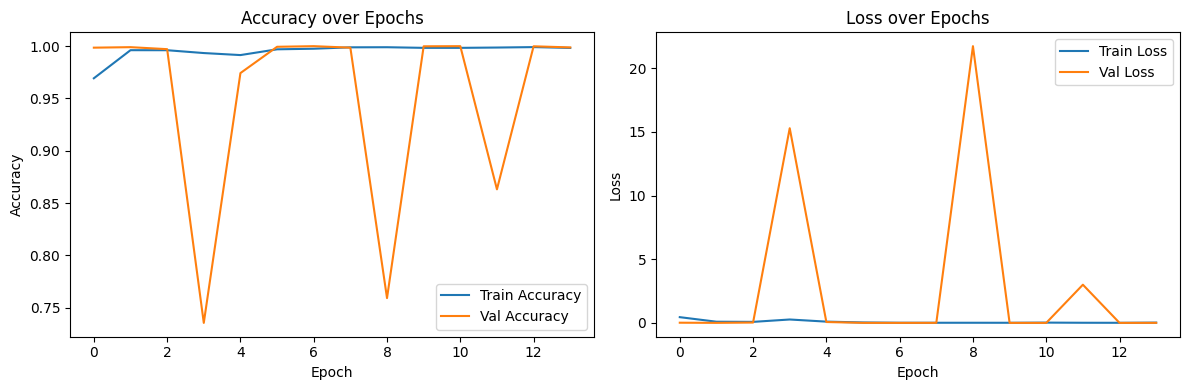

775/775 ━━━━━━━━━━━━━━━━━━━━ 304s 391ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Final Test Accuracy (on original imbalanced test set): 1.0000
Final Test Loss: 0.0000
775/775 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step


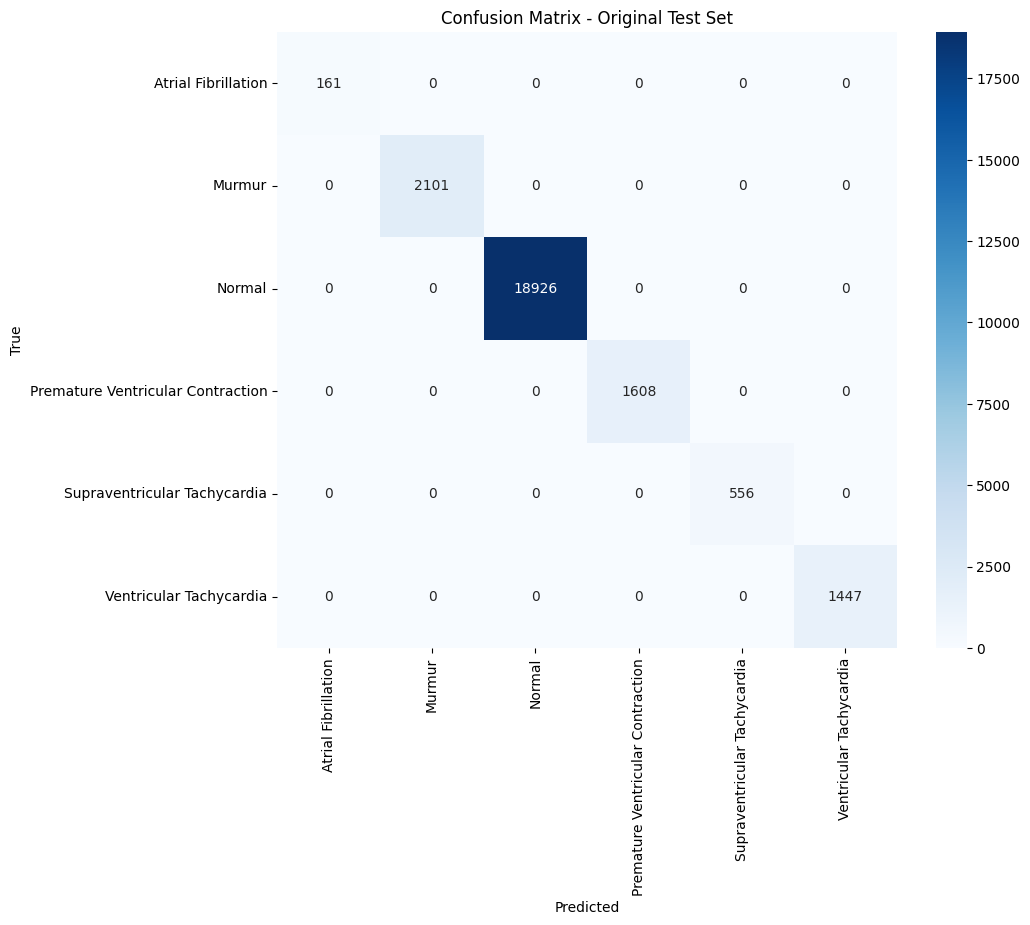

Classification Report on Original Test Set:
                                   precision    recall  f1-score   support

              Atrial Fibrillation       1.00      1.00      1.00       161
                           Murmur       1.00      1.00      1.00      2101
                           Normal       1.00      1.00      1.00     18926
Premature Ventricular Contraction       1.00      1.00      1.00      1608
     Supraventricular Tachycardia       1.00      1.00      1.00       556
          Ventricular Tachycardia       1.00      1.00      1.00      1447

                         accuracy                           1.00     24799
                        macro avg       1.00      1.00      1.00     24799
                     weighted avg       1.00      1.00      1.00     24799



In [9]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Define CNN Model (same as yours)
def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(160, 160, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(6, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_cnn_model()
model.summary()

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_cnn_balanced_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

# Train the model
history = model.fit(
    train_generator,
    epochs=17,                    # Can go higher now that data is balanced
    validation_data=val_generator,
    callbacks=callbacks
)

# Save final model
model.save('/kaggle/working/cnn_ecg_balanced_final.h5')


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Load the best saved model
best_model = models.load_model('/kaggle/working/best_cnn_balanced_model.h5')

# Evaluate on original test set
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"\nFinal Test Accuracy (on original imbalanced test set): {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Predictions
y_pred = best_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
class_labels = list(test_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Original Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report (shows per-class precision/recall/F1)
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print("Classification Report on Original Test Set:")
print(report)